In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [2]:
df = pd.read_csv("../data/cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df['sum_gamerounds'].min()

np.int64(0)

Some business questions to be answered

## Observed Groups

Control Group: Players encountered the first gate at level 30

Treatment Group: Players encountered the first gate at level 40


### What improves player retention more?

Placing the gate at an earlier date? (Level 30) bettter long-term retention

Placing the gate at a later date? (level 40) better retention

In [4]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [5]:
df.groupby('version')[['retention_1', 'retention_7']].value_counts(normalize="True").unstack()

retention_7             False     True 
version retention_1                    
gate_30 False        0.510962  0.040850
        True         0.298837  0.149351
gate_40 False        0.518741  0.038976
        True         0.299259  0.143024

What happened in the sample, a quick descriptive analysis on each version

In [6]:
categories = df['version'].unique()

def get_retention_count(retetion_value, retention_day):
    value_counts = []
    for category in categories:
        print(category)
        cat_count = df[(df['version'] == category) & (df[retention_day] == retetion_value)][retention_day].count()
        value_counts.append(cat_count)
    # return some array
    return value_counts

ret7_true = get_retention_count(True, 'retention_7')
print(ret7_true)

print(len(categories))

gate_30
gate_40
[np.int64(8502), np.int64(8279)]
2


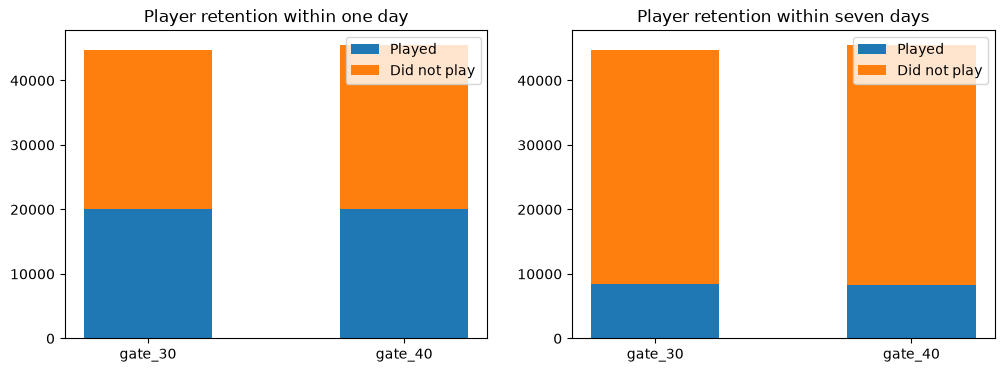

In [7]:
categories = df['version'].unique()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

width=0.5

def get_retention_count(retetion_value, retention_day):
    value_counts = []
    for category in categories:
        df[(df['version'] == category) & (df[retention_day] == retetion_value)][retention_day].count()
        cat_count = df[(df['version'] == category) & (df[retention_day] == retetion_value)][retention_day].count()
        value_counts.append(cat_count)
    # return some array
    return value_counts

retention_proportions = {
    'retention_1_proprtions': {
        'Played': get_retention_count(True, 'retention_1'),
        'Did not play': get_retention_count(False, 'retention_1')
    },
    'retention_7_proprtions': {
        'Played': get_retention_count(True, 'retention_7'),
        'Did not play': get_retention_count(False, 'retention_7')
    }
}

i = 0
for _, retention_proportion in retention_proportions.items():
    bottom = np.zeros(len(categories))
    for boolean, ret_count in retention_proportion.items():
        p = axs[i].bar(categories, ret_count, width, label=boolean, bottom=bottom)
        bottom += ret_count
        
    i += 1

axs[0].set_title("Player retention within one day")
axs[1].set_title("Player retention within seven days")
axs[0].legend(loc="upper right")        
axs[1].legend(loc="upper right")        

# axs.set_title("Did player played for 7 days after installing")
# axs.legend(loc="upper right")

plt.show()

plt.show()

How confident we are that the difference is real

## For both retentions (Within 1 day and 7 days)

1. Null hypotheses: Placing a gate at a different level does not improve player retention

2. Alternative Hypotheses: Placing the gate at a different level would improve player retention

In [8]:
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

# First test for retention within one day
n_con = df[(df['version'] == 'gate_30')]
n_trt = df[(df['version'] == 'gate_40')]

# success
p_con = n_con[n_con['retention_1'] == True].shape[0]
p_trt = n_trt[n_trt['retention_1'] == True].shape[0]

count = [p_con, p_trt]
nobs = [n_con.shape[0], n_trt.shape[0]]


zstat, pval = proportions_ztest(count, nobs)
print('P Value: {0:0.3f}'.format(pval))
print('Z statistic: ', zstat)

# alpha
alpha = 0.05

# critical z value
z_critical_two_tailed = stats.norm.ppf(1 - alpha/2)

if (pval > alpha):
    print("We fail to reject the null hypotheses, so changing the level gate does not produce different 1 day retentions")
else:
    print("We reject the null hypotheses, indicating that there is a significant difference in 1 day retention when changing the gate placement")



P Value: 0.074
Z statistic:  1.7840862247974725
We fail to reject the null hypotheses, so changing the level gate does not produce different 1 day retentions


In [9]:
# First test for retention within seven days

# success
p_con = n_con[n_con['retention_7'] == True].shape[0]
p_trt = n_trt[n_trt['retention_7'] == True].shape[0]

count = [p_con, p_trt]
nobs = [n_con.shape[0], n_trt.shape[0]]


zstat, pval = proportions_ztest(count, nobs)
print('P Value: {0:0.3f}'.format(pval))
print('Z statistic: ', zstat)

# alpha
alpha = 0.05

# critical z value
z_critical_two_tailed = stats.norm.ppf(1 - alpha/2)

if (pval > alpha):
    print("We fail to reject the null hypotheses, so changing the level gate does not produce different 7 day retentions")
else:
    print("We reject the null hypotheses, indicating that there is a significant difference in 7 day retention when changing the gate placement")



P Value: 0.002
Z statistic:  3.164358912748191
We reject the null hypotheses, indicating that there is a significant difference in 7 day retention when changing the gate placement


In [10]:
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

# Ratio Analysis
ratio_g30 = (gate_30.shape[0]/df.shape[0]) * 100
ratio_g40 = (gate_40.shape[0]/df.shape[0]) * 100

print(f'gate_30: {ratio_g30:.2f} %')
print(f'gate_40: {ratio_g40:.2f} %')


gate_30: 49.56 %
gate_40: 50.44 %


We would also like to calculate if there is any significant difference between the mean of the total games play between the two groups.

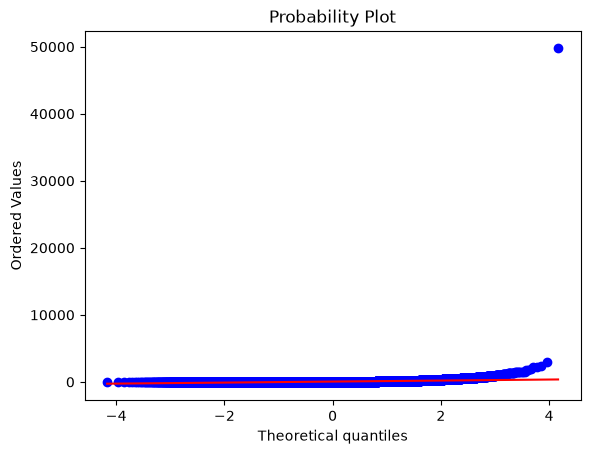

In [11]:
from scipy import stats

# Check for data normallity

# Samples gamerounds for each group
gamerounds_30 = df[(df['version'] == 'gate_30')]['sum_gamerounds']
gamerounds_40 = df[(df['version'] == 'gate_40')]['sum_gamerounds']

grp30norm = stats.probplot(gamerounds_30, plot=plt)

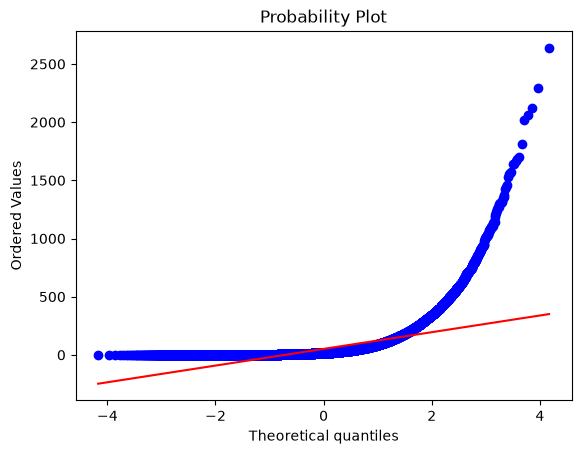

In [12]:
grp40norm = stats.probplot(gamerounds_40, plot=plt)

In [13]:
# Remove some outliers

# Calculate the 99th percentile threshold
threshold = df['sum_gamerounds'].quantile(0.99)

df_cleaned = df[df['sum_gamerounds'] < threshold]

print(f"Removed {(len(df) - len(df_cleaned))} outliers.")

Removed 906 outliers.


In [14]:
df_cleaned

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


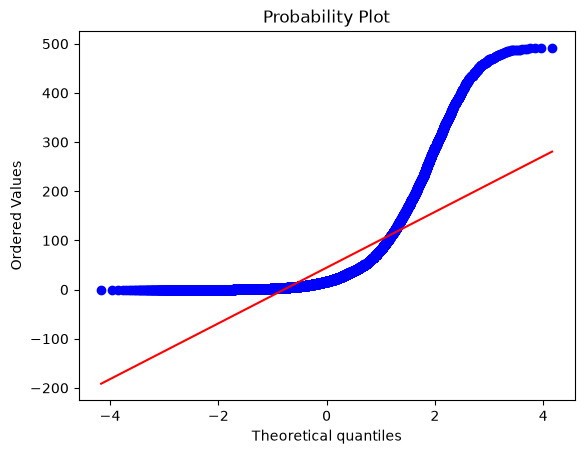

In [15]:
# Check for data normallity again

# Samples gamerounds for each group
gamerounds_30 = df_cleaned[(df_cleaned['version'] == 'gate_30')]['sum_gamerounds']
gamerounds_40 = df_cleaned[(df_cleaned['version'] == 'gate_40')]['sum_gamerounds']

grp30norm = stats.probplot(gamerounds_30, plot=plt)

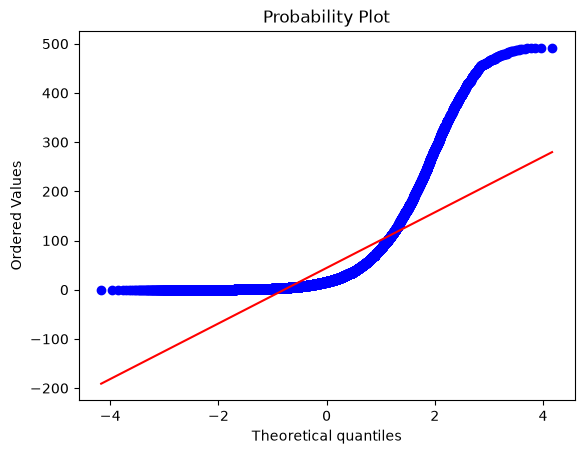

In [16]:
grp40norm = stats.probplot(gamerounds_40, plot=plt)

In [24]:
# One sample KS test for group A and B

res = stats.ks_1samp(gamerounds_30, stats.norm.cdf)
print(res.pvalue)
res = stats.ks_1samp(gamerounds_40, stats.norm.cdf)
print(res.pvalue)

0.0
0.0


<Axes: xlabel='sum_gamerounds', ylabel='Proportion'>

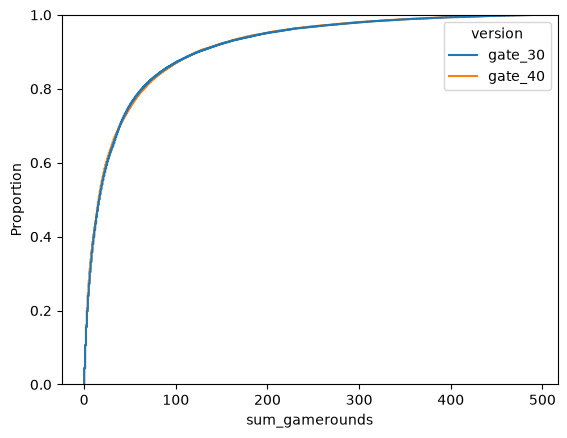

In [31]:
sns.ecdfplot(data=df_cleaned, x="sum_gamerounds", label="gamerounds for gate 30", hue="version")

In [18]:
from scipy.stats import mannwhitneyu

# Run Welch's T-Test
u_stat, p_value = mannwhitneyu(gamerounds_30, gamerounds_40)

print(f"u-statistic: {u_stat:.3f}")
print(f"p-value: {p_value:.3f}")


u-statistic: 1003924146.000
p-value: 0.049


In [19]:
print("Gate 30 Summary:")
print(gamerounds_30.describe())
print("\nGate 40 Summary:")
print(gamerounds_40.describe())

Gate 30 Summary:
count    44249.000000
mean        44.611833
std         71.967017
min          0.000000
25%          5.000000
50%         16.000000
75%         48.000000
max        492.000000
Name: sum_gamerounds, dtype: float64

Gate 40 Summary:
count    45034.000000
mean        44.366501
std         71.448313
min          0.000000
25%          5.000000
50%         16.000000
75%         50.000000
max        492.000000
Name: sum_gamerounds, dtype: float64
